## Setup & data exploration

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from dotenv import load_dotenv

load_dotenv()

ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds['train'].to_pandas()

# Filter for English tickets
df = df[df['language'] == 'en'].copy()


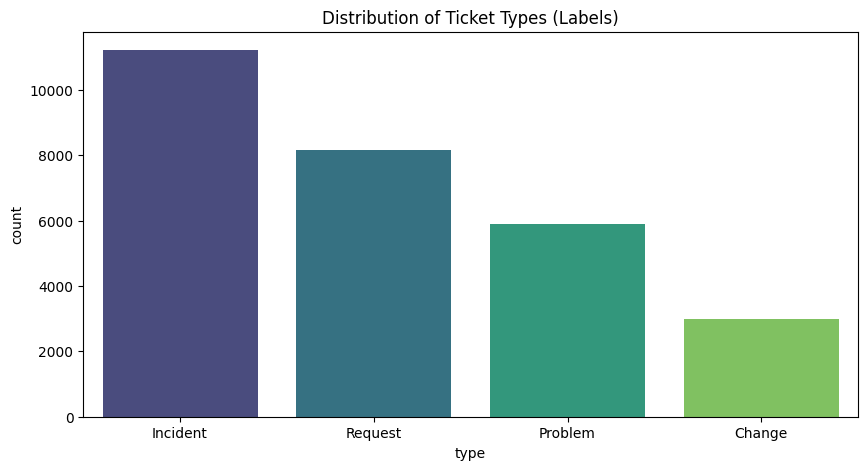

In [11]:
# Visualize label distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='type', hue='type', palette='viridis', order=df['type'].value_counts().index, legend=False)
plt.title("Distribution of Ticket Types (Labels)")
plt.show()

Average words per ticket: 55.35


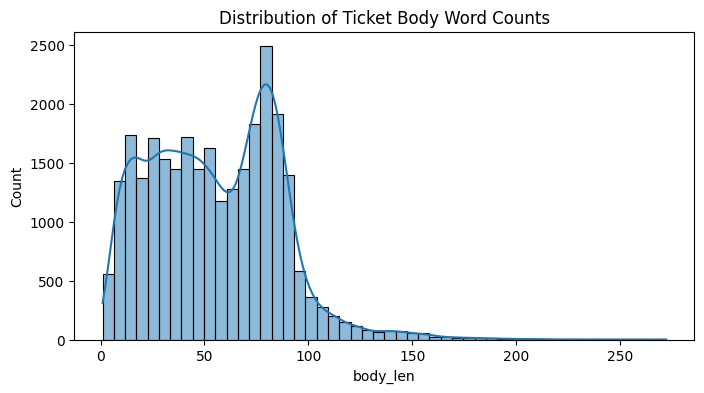

In [12]:
# Check ticket lengths
df['body_len'] = df['body'].apply(lambda x: len(str(x).split()))
print(f"Average words per ticket: {df['body_len'].mean():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df['body_len'], bins=50, kde=True)
plt.title("Distribution of Ticket Body Word Counts")
plt.show()


## Data preparation

In [16]:
# Target label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['type'])
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(f"Mapping: {label_mapping}")

# Select columns and rename "body" to "text" to match what Hugging Face NLP pipelines expect.
data = df[['body', 'label']].rename(columns={'body': 'text'})
df['body'] = df['body'].fillna('')

# Train test split (80/20)
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['label'])

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Mapping: {'Change': 0, 'Incident': 1, 'Problem': 2, 'Request': 3}
Training samples: 22608
Testing samples: 5653


## Task implementation

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# dictionary to store metrics for final comparison
model_results = {}

# Helper function to log results
def log_result(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    model_results[model_name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

### Method 1 - Logistic Regression + Bag-of-Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# Vectorization
vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_train_bow = vectorizer.fit_transform(train_df['text'].fillna(''))
X_test_bow = vectorizer.transform(test_df['text'].fillna(''))
y_train = train_df['label']
y_test = test_df['label']

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_bow, y_train)

# Predict & Evaluate
log_preds = log_reg.predict(X_test_bow)
log_result("Logistic Regression (BoW)", y_test, log_preds)

--- Logistic Regression (BoW) Results ---
Accuracy: 0.8459
F1-Score: 0.8429

              precision    recall  f1-score   support

      Change       0.96      0.94      0.95       598
    Incident       0.80      0.86      0.83      2243
     Problem       0.68      0.59      0.63      1179
     Request       0.97      0.99      0.98      1633

    accuracy                           0.85      5653
   macro avg       0.85      0.84      0.85      5653
weighted avg       0.84      0.85      0.84      5653



### Method 2 - Fine-Tuned Neural Network (BERT)

In [19]:
import torch
from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

train_df['text'] = train_df['text'].fillna('')
test_df['text'] = test_df['text'].fillna('')

# Convert pandas to Hugging Face dataset specifically
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)
# Tokenization
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
def tokenize_bert(batch):
    return bert_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)
train_ds = train_ds.map(tokenize_bert, batched=True)
test_ds = test_ds.map(tokenize_bert, batched=True)
# Model initialization
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", 
    num_labels=len(le.classes_)
)
# Training
training_args = TrainingArguments(
    output_dir="./bert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch", # Evaluates at end of every epoch
    save_strategy="epoch",
)
bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)
bert_trainer.train()
# Predict and evaluate
raw_preds = bert_trainer.predict(test_ds)
bert_preds = np.argmax(raw_preds.predictions, axis=1)
log_result("BERT Fine-Tuned", test_df['label'], bert_preds)

Map:   0%|          | 0/22608 [00:00<?, ? examples/s]

Map:   0%|          | 0/5653 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/marcellpetras/Desktop/NLP-home-assignment/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/marcellpetras/Desktop/NLP-home-assignment/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


--- BERT Fine-Tuned Results ---
Accuracy: 0.8912
F1-Score: 0.8894

              precision    recall  f1-score   support

      Change       0.98      0.99      0.98       598
    Incident       0.85      0.90      0.87      2243
     Problem       0.78      0.69      0.73      1179
     Request       0.99      0.99      0.99      1633

    accuracy                           0.89      5653
   macro avg       0.90      0.89      0.90      5653
weighted avg       0.89      0.89      0.89      5653



### Method 3 - Gemma 3 (PEFT + QLoRA)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType

# Note: Update model string to the specific Gemma model you have accepted the TOS for!
gemma_model_id = "google/gemma-2-2b-it" # or "google/gemma-3-4b-it" 

# 1. Quantization Configuration (Loads model in 4-bit)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# 2. Tokenization 
gemma_tokenizer = AutoTokenizer.from_pretrained(gemma_model_id)
# Gemma does not explicitly have a padding token out of the box so we borrow EOS
gemma_tokenizer.pad_token = gemma_tokenizer.eos_token 

def tokenize_gemma(batch):
    return gemma_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds_gemma = Dataset.from_pandas(train_df).map(tokenize_gemma, batched=True)
test_ds_gemma = Dataset.from_pandas(test_df).map(tokenize_gemma, batched=True)

# 3. Load Model using 4-bit Quantization
gemma_base = AutoModelForSequenceClassification.from_pretrained(
    gemma_model_id,
    num_labels=len(le.classes_),
    quantization_config=bnb_config,
    device_map="auto"
)
gemma_base.config.pad_token_id = gemma_tokenizer.pad_token_id

# 4. LoRA Setup (PEFT)
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,              # Rank
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"] # Most common target modules for attention
)
gemma_peft_model = get_peft_model(gemma_base, peft_config)
gemma_peft_model.print_trainable_parameters()

# 5. Training
gemma_args = TrainingArguments(
    output_dir="./gemma_results",
    learning_rate=2e-4, # Notice LR is higher for LoRA adapters normally!
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch"
)

gemma_trainer = Trainer(
    model=gemma_peft_model,
    args=gemma_args,
    train_dataset=train_ds_gemma,
    eval_dataset=test_ds_gemma,
)

gemma_trainer.train()

# 6. Predict & Evaluate
raw_preds_gemma = gemma_trainer.predict(test_ds_gemma)
gemma_preds = np.argmax(raw_preds_gemma.predictions, axis=1)
log_result("Gemma 3 (QLoRA)", test_df['label'], gemma_preds)
